<a href="https://colab.research.google.com/github/fael83/Smt4-Data-Mining/blob/main/Week10_Latihan1_Data_Kelas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Dataset Kelas SIB 2G.csv to Dataset Kelas SIB 2G.csv


In [3]:
df = pd.read_csv('Dataset Kelas SIB 2G.csv')
print(df.head())

            Timestamp                            Nama Tempat Lahir  \
0  2/10/2026 18:47:53           Pratama Angga Saputra       Malang   
1  2/10/2026 18:55:03  Muchammad Nabil Haykal Widarto  Kota Malang   
2  2/10/2026 18:55:51              Moh. Rafael Abrari     Lamongan   
3  2/10/2026 19:49:44          Muhamad Miftahul Akmal      Cilegon   
4  2/10/2026 19:54:36     Narendra Daniswara Alamsyah   Bojonegoro   

  Tanggal Lahir Jenis Kelamin  Tinggi Badan (cm)  Berat Badan (kg)  \
0     7/10/2005     Laki-Laki                165                52   
1     3/22/2004     Laki-Laki                175               123   
2    11/27/2006     Laki-Laki                230                55   
3      3/5/2005     Laki-Laki                168                70   
4     2/16/2006     Laki-Laki                166                64   

     Kota Asal                Alamat Domisili Saat Ini Jenis Kendaraan Utama  \
0       Malang      Jl. Mergan lori 2b no 51 RT 5 RW 6                 Motor  

In [4]:
features = ['Usia (tahun)', 'Tinggi Badan (cm)']
X = df[features]

In [5]:
# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# K-Means dengan 3 cluster
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Lihat hasil clustering
print(df.head())

            Timestamp                            Nama Tempat Lahir  \
0  2/10/2026 18:47:53           Pratama Angga Saputra       Malang   
1  2/10/2026 18:55:03  Muchammad Nabil Haykal Widarto  Kota Malang   
2  2/10/2026 18:55:51              Moh. Rafael Abrari     Lamongan   
3  2/10/2026 19:49:44          Muhamad Miftahul Akmal      Cilegon   
4  2/10/2026 19:54:36     Narendra Daniswara Alamsyah   Bojonegoro   

  Tanggal Lahir Jenis Kelamin  Tinggi Badan (cm)  Berat Badan (kg)  \
0     7/10/2005     Laki-Laki                165                52   
1     3/22/2004     Laki-Laki                175               123   
2    11/27/2006     Laki-Laki                230                55   
3      3/5/2005     Laki-Laki                168                70   
4     2/16/2006     Laki-Laki                166                64   

     Kota Asal                Alamat Domisili Saat Ini Jenis Kendaraan Utama  \
0       Malang      Jl. Mergan lori 2b no 51 RT 5 RW 6                 Motor  

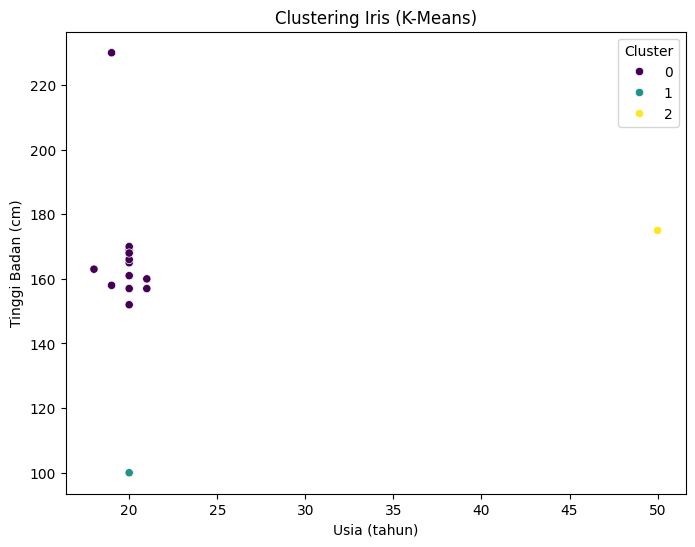

In [7]:
# Visualisasi hasil clustering
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Usia (tahun)'],
    y=df['Tinggi Badan (cm)'],
    hue=df['Cluster'],
    palette='viridis'
)
plt.title("Clustering Iris (K-Means)")
plt.show()


Silhouette Score: 0.677
Inertia (k=3): 8.334


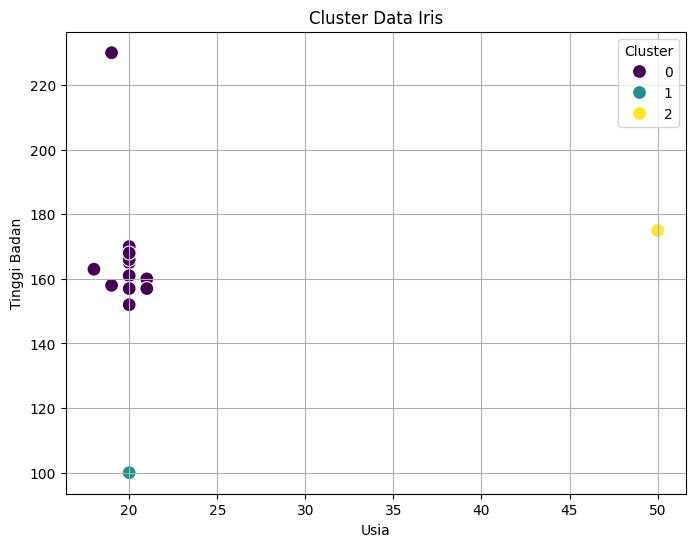

In [8]:
# Silhouette Score
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
print(f"\nSilhouette Score: {silhouette_avg:.3f}")

# Inertia
print(f"Inertia (k=3): {kmeans.inertia_:.3f}")

# Visualisasi (pakai fitur Iris)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Usia (tahun)'],
    y=df['Tinggi Badan (cm)'],
    hue=df['Cluster'],
    palette='viridis',
    s=100
)

plt.title('Cluster Data Iris')
plt.xlabel('Usia')
plt.ylabel('Tinggi Badan')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()